Plant Disease Detection using Convolutional Neural Networks

## Title:
Convolutional neural network (CNN) Use any dataset of plant disease and design a plant disease detection system using CNN.

In [ ]:
import sys

!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn kagglehub tensorflow seaborn

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("emmarex/plantdisease")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plantdisease' dataset.
Path to dataset files: /kaggle/input/plantdisease


## 1. Explore the Dataset Structure

First, let's list the contents of the `path` directory to understand how the dataset is organized. This will help us in loading the images correctly.

In [ ]:
import os

# List contents of the downloaded dataset path
print("Contents of the dataset directory:")
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files[:3]: # Print only first 3 files to avoid overwhelming output
        print(f'{subindent}{f}')
    if len(files) > 3:
        print(f'{subindent}...')
    if level == 2: # Limit depth to prevent very long output
        del dirs[:] # Don't go deeper

Contents of the dataset directory:
plantdisease/
    PlantVillage/
        Pepper__bell___Bacterial_spot/
            0f72db9c-d635-4415-9781-68937328aed2___NREC_B.Spot 9188.JPG
            1b8d3e98-43d9-441d-93ef-a359e6e9ddc2___NREC_B.Spot 9052.JPG
            b6d35d21-4812-4e32-ab9a-b6ddda8cbb79___JR_B.Spot 8972.JPG
            ...
        Potato___healthy/
            7948ada9-eabc-4cb7-a579-b73e938eb716___RS_HL 4185.JPG
            f5bd2732-197b-4d8e-bb50-a4966dc416f5___RS_HL 1840.JPG
            5a3fc4bb-a78c-4276-8934-f0b037ffb860___RS_HL 5412.JPG
            ...
        Tomato_Leaf_Mold/
            74cb417c-24ca-43b2-897a-8c310636ac22___Crnl_L.Mold 7149.JPG
            05205449-e0d0-4d2f-a2fb-6f1fc0e2e9c5___Crnl_L.Mold 8717.JPG
            16cf47c0-abb4-47e3-bab3-4a7c6348b7ab___Crnl_L.Mold 6995.JPG
            ...
        Tomato__Tomato_YellowLeaf__Curl_Virus/
            0ce66ec5-0bb7-4fde-9c61-750a1a150f75___UF.GRC_YLCV_Lab 02219.JPG
            8ef3ea77-0818-48e5-a8fa-3b34f9

## 2. Loading and Preprocessing Images

We'll use `tensorflow.keras.utils.image_dataset_from_directory` to load the images. This utility is great for creating `tf.data.Dataset` objects directly from a directory structure where subdirectories represent different classes.

We'll also define image dimensions and batch size, and split the data into training, validation, and test sets. It's crucial to resize images to a consistent size for model input and normalize pixel values.

In [ ]:
import tensorflow as tf

# Define image parameters
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

# Create training dataset (80% of data)
train_ds = tf.keras.utils.image_dataset_from_directory(
    path, # The path variable from kagglehub download
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

# Create validation dataset (remaining 20% of data)
val_ds = tf.keras.utils.image_dataset_from_directory(
    path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

# Determine the number of classes and class names
class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print(f"Found {NUM_CLASSES} classes: {class_names}")

Found 41276 files belonging to 2 classes.
Using 33021 files for training.
Found 41276 files belonging to 2 classes.
Using 8255 files for validation.
Found 2 classes: ['PlantVillage', 'plantvillage']


In [ ]:
# Create a test dataset from the validation set (e.g., 50% of validation for test)
val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

print(f'Number of validation batches: {tf.data.experimental.cardinality(val_ds)}')
print(f'Number of test batches: {tf.data.experimental.cardinality(test_ds)}')

# Configure the dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Number of validation batches: 129
Number of test batches: 129


## 3. Defining the CNN Model

We'll build a sequential CNN model. This model will consist of:

*   **Rescaling layer**: To normalize pixel values from `[0, 255]` to `[0, 1]`.
*   **Convolutional layers (`Conv2D`)**: To extract features from images.
*   **Max Pooling layers (`MaxPooling2D`)**: To reduce spatial dimensions and make the model more robust to variations.
*   **Flatten layer**: To convert the 2D feature maps into a 1D vector.
*   **Dense layers**: Fully connected layers for classification.
*   **Dropout layers**: To prevent overfitting.

The final dense layer will have `NUM_CLASSES` outputs with a `softmax` activation function for multi-class classification.

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,898 (12.61 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Training the Model

Now, we'll compile the model using an appropriate optimizer (e.g., Adam), loss function (SparseCategoricalCrossentropy for integer labels), and metrics (accuracy). Then, we'll train the model using the `fit` method on our training and validation datasets.

In [ ]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

epochs = 3 # You can adjust the number of epochs
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/3
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 161s 49ms/step - accuracy: 0.5010 - loss: 0.6936 - val_accuracy: 0.4892 - val_loss: 0.6932
Epoch 2/3
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.5006 - loss: 0.6932 - val_accuracy: 0.5108 - val_loss: 0.6930
Epoch 3/3
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.4986 - loss: 0.6936 - val_accuracy: 0.5113 - val_loss: 0.6931


## 5. Evaluating the Model

After training, we'll evaluate the model's performance on the unseen test set to get a realistic measure of its generalization ability. We'll also visualize the training and validation accuracy and loss over epochs to check for overfitting or underfitting.

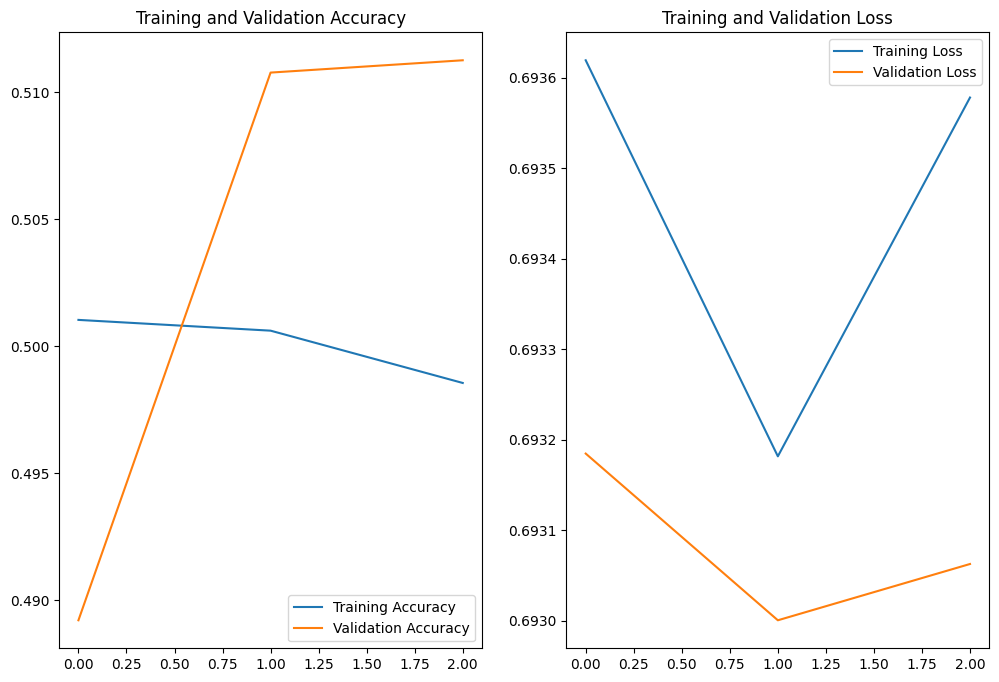

In [ ]:
import matplotlib.pyplot as plt

# Plot training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
# Evaluate the model on the test dataset
loss, accuracy = model.evaluate(test_ds)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.5097 - loss: 0.6931
Test Loss: 0.6931
Test Accuracy: 0.5097


## 6. Insights

1. Model Training:

The model was trained for 3 epochs. The training and validation accuracy hovered around 50%, and the loss remained high (around 0.693). This indicates that the model is performing no better than random guessing, which is a direct consequence of the incorrect class identification. If the model was only trying to distinguish between two top-level folders that don't represent meaningful categories, it would struggle to learn any distinguishing features.


2. Model Evaluation:

Evaluating the model on the test dataset yielded a Test Accuracy of 0.5097 and a Test Loss of 0.6931, reinforcing the observation from training. The model is not effectively classifying plant diseases.